Importing libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Loading/Reading Dataset

In [3]:
df=pd.read_csv(r'C:\Users\saba\Downloads\student_mental_health_burnout.csv')
df.head(5)

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


## Section 1: Data Understanding

1. How many rows and columns are present in the dataset? Based on the sample provided,
what is the total number of unique students?

In [4]:
# Rows and columns
print(df.shape)

# Unique students (assuming column name 'student_id')
print(df['student_id'].nunique())

(150000, 20)
150000


2. Which columns have missing values? Examine the provided sample are there any visible
missing entries? How would you systematically check for missing values across the
entire dataset?


In [5]:
# Columns with missing values
print(df.columns[df.isnull().any()])

# Count of missing values per column
print(df.isnull().sum())

Index([], dtype='str')
student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64


3. Identify all categorical, numerical, and ordinal columns in the dataset. Justify your
classification for each.


In [6]:
categorical = ['gender', 'course', 'sleep_quality', 'stress_level']
numerical = ['cgpa', 'daily_study_hours', 'screen_time_hours', 'anxiety_score']
ordinal = ['year_of_study']  # can include 'sleep_quality' if ordered

print("Categorical:", categorical)
print("Numerical:", numerical)
print("Ordinal:", ordinal)

Categorical: ['gender', 'course', 'sleep_quality', 'stress_level']
Numerical: ['cgpa', 'daily_study_hours', 'screen_time_hours', 'anxiety_score']
Ordinal: ['year_of_study']


4. Calculate the mean, median, and standard deviation for cgpa, daily_study_hours, and
screen_time_hours.


In [7]:
print(df[['cgpa','daily_study_hours','screen_time_hours']].agg(['mean','median','std']))

            cgpa  daily_study_hours  screen_time_hours
mean    6.997389           5.507869           6.502819
median  6.990000           5.500000           6.500000
std     1.732180           2.595592           3.178948


5. Which gender has the highest average anxiety_score? Provide the exact value

In [8]:
gender_anxiety = df.groupby('gender')['anxiety_score'].mean()
highest_gender = gender_anxiety.idxmax()
highest_value = gender_anxiety.max()
print(highest_gender, highest_value)

Male 5.502862060683692


6. List all unique course values and calculate the proportion of students in each course.


In [9]:
print(df['course'].value_counts())          # counts
print(df['course'].value_counts(normalize=True).sum())  # proportion

course
MBA      25231
BBA      25103
BCA      24973
MCA      24950
BSc      24894
BTech    24849
Name: count, dtype: int64
1.0


7. What is the distribution of year of study? How many students are in each academic
year?


In [10]:
# Check all column names
print(df.columns)

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='str')


In [11]:
print(df['year'].value_counts())

year
1st    37680
4th    37622
3rd    37422
2nd    37276
Name: count, dtype: int64


8. Compare the average cgpa between students with sleep_quality = "Good" vs "Poor".

In [12]:
print(df.groupby('sleep_quality')['cgpa'].mean())

sleep_quality
Average    6.991159
Good       7.013745
Poor       6.987189
Name: cgpa, dtype: float64


9. What is the correlation between daily_study_hours and cgpa in the sample?


In [13]:
print(df['daily_study_hours'].corr(df['cgpa']))

-0.005449724676499281


10. Which stress_level category appears most frequently, and what is its percentage?

In [14]:
most_stress = df['stress_level'].value_counts().idxmax()
percentage = (df['stress_level'].value_counts().max()/len(df))*100
print(most_stress, percentage)

High 33.53


## Section 2: Data Cleaning & Preprocessing (Complex)

## Missing Value Handling


a. How many rows contain at least one NaN value?

In [15]:
# Count rows with at least one missing value
print(df.isnull().any(axis=1).sum())

0


b. If missing values exist, what strategies would you use for numerical columns vs categorical
columns? Provide at least two different imputation methods for each type with justification.

In [16]:
# Numerical columns (e.g., cgpa, daily_study_hours):

# Mean imputation – replace missing values with the mean of the column
# Median imputation – replace missing values with the median of the column

# Categorical columns (e.g., gender, course):

# Mode imputation – replace missing values with the most frequent category
# Constant/placeholder imputation – replace missing values with a placeholder like "Unknown"

c. Are there any rows with all NaN values? How would you handle them?

In [17]:
# Count rows where all values are NaN
print(df.isnull().all(axis=1).sum())
# If any rows have all NaN values, they can be safely dropped because they contain no useful information:
df = df.dropna(how='all')

0


## Duplicate Detection

a. How many duplicate rows exist? What columns would you consider to define a duplicate
record?

In [18]:
# Count duplicate rows
print(df.duplicated().sum())

# To define duplicates, usually use all columns that uniquely identify a student
duplicate_columns = ['student_id', 'age', 'gender' 'course', 'year']
print(duplicate_columns)

0
['student_id', 'age', 'gendercourse', 'year']


b. If duplicates are found, what effect might keeping them have on logistic regression model
performance?

In [19]:
# Keeping duplicates can bias the model, giving more weight to repeated records.
# This can lead to overfitting, reducing the model’s ability to generalize to new data.

## Outlier Detection & Treatment


a. Use the IQR method to detect outliers. How many outliers exist in each?


In [20]:
numerical_cols = ['cgpa','daily_study_hours','screen_time_hours','anxiety_score']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col} outliers:", outliers.shape[0])

cgpa outliers: 0
daily_study_hours outliers: 0
screen_time_hours outliers: 0
anxiety_score outliers: 0


b. Apply two different outlier treatment methods (iqr and transformation) and explain which you
would choose for logistic regression and why.

In [21]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = df[col].clip(lower, upper)

2. Transformation (e.g., log or square root) – reduces skewness:

In [22]:
import numpy as np
df['cgpa_log'] = np.log1p(df['cgpa'])  # handles zero values

WHY?

In [23]:
# IQR capping is preferred because logistic regression assumes linear relationship 
# and interpretable scales; transformations can sometimes distort interpretability

## Encoding Categorical Variables


a. Identify all categorical columns and explain why they need encoding.


In [24]:
categorical_cols = ['gender','course','sleep_quality','stress_level','internet_quality','burnout_level']
# Encoding is needed because ML models require numeric input
print(categorical_cols)

['gender', 'course', 'sleep_quality', 'stress_level', 'internet_quality', 'burnout_level']


b. Apply both One-Hot Encoding and Label Encoding to appropriate columns. Compare the
results.

In [25]:
# One-Hot Encoding (for non-ordinal categories)
df_onehot = pd.get_dummies(df, columns=['gender','course','internet_quality','burnout_level'], drop_first=True)
print(df_onehot.head())

   student_id  age year  daily_study_hours  daily_sleep_hours  \
0      100001   23  1st                4.3                6.8   
1      100002   20  3rd                1.4                4.7   
2      100003   24  4th                3.7                4.8   
3      100004   21  4th                1.6                6.7   
4      100005   23  4th                2.0                6.7   

   screen_time_hours stress_level  anxiety_score  depression_score  \
0                6.1         High             10                 3   
1                3.0         High              2                10   
2                1.5          Low              2                 7   
3                7.0         High              3                 3   
4                5.4         High              7                 7   

   academic_pressure_score  ...  gender_Other  course_BCA  course_BSc  \
0                        4  ...         False       False       False   
1                        8  ...         Fa

Label Encoding

In [26]:
from sklearn.preprocessing import LabelEncoder

df_label = df.copy()
le = LabelEncoder()
for col in ['gender','course','internet_quality','burnout_level']:
    df_label[col] = le.fit_transform(df_label[col])
print(df_label.head())

   student_id  age  gender  course year  daily_study_hours  daily_sleep_hours  \
0      100001   23       1       3  1st                4.3                6.8   
1      100002   20       1       3  3rd                1.4                4.7   
2      100003   24       0       1  4th                3.7                4.8   
3      100004   21       1       2  4th                1.6                6.7   
4      100005   23       2       2  4th                2.0                6.7   

   screen_time_hours stress_level  anxiety_score  ...  \
0                6.1         High             10  ...   
1                3.0         High              2  ...   
2                1.5          Low              2  ...   
3                7.0         High              3  ...   
4                5.4         High              7  ...   

   academic_pressure_score  financial_stress_score  social_support_score  \
0                        4                       2                     6   
1                 

c. For sleep_quality (Average, Good, Poor) and stress_level (Low, Medium, High), why is
ordinal encoding more appropriate than one-hot encoding? Implement it.

In [27]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ['sleep_quality','stress_level']
ordinal_categories = [
    ['Poor','Average','Good'],   # sleep_quality
    ['Low','Medium','High']      # stress_level
]

oe = OrdinalEncoder(categories=ordinal_categories)
df[ordinal_cols] = oe.fit_transform(df[ordinal_cols])
print(df[ordinal_cols].head())

   sleep_quality  stress_level
0            1.0           2.0
1            0.0           2.0
2            2.0           0.0
3            0.0           2.0
4            2.0           2.0


Why ordinal is better:

These columns have natural order (Poor < Average < Good, Low < Medium < High).
One-Hot would remove the order; ordinal encoding preserves it, which is useful for logistic regression.

## Feature Scaling

a. Explain why standardization (Z-score) is recommended for logistic regression.

Standardization (Z-score) is recommended for logistic regression because it puts all numerical features on the same scale (mean = 0, std = 1), preventing features with larger ranges from dominating the model and ensuring faster convergence and more reliable coefficients.

b. Apply StandardScaler to all numerical features. Show the mean and standard deviation of
scaled features to verify.

In [28]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['age','daily_study_hours','daily_sleep_hours','screen_time_hours',
                  'anxiety_score','depression_score','academic_pressure_score',
                  'financial_stress_score','social_support_score','physical_activity_hours',
                  'attendance_percentage','cgpa']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Verify mean and std
print(df[numerical_cols].agg(['mean','std']))

               age  daily_study_hours  daily_sleep_hours  screen_time_hours  \
mean  4.244309e-17      -1.139237e-16       3.149125e-16       8.801256e-17   
std   1.000003e+00       1.000003e+00       1.000003e+00       1.000003e+00   

      anxiety_score  depression_score  academic_pressure_score  \
mean  -2.576902e-17      1.256240e-16             7.152797e-17   
std    1.000003e+00      1.000003e+00             1.000003e+00   

      financial_stress_score  social_support_score  physical_activity_hours  \
mean            8.867573e-17         -1.529088e-16             1.688250e-16   
std             1.000003e+00          1.000003e+00             1.000003e+00   

      attendance_percentage          cgpa  
mean           7.707020e-16 -5.580129e-16  
std            1.000003e+00  1.000003e+00  


## Data Type Validation

After preprocessing, verify that all columns have appropriate data types for modeling. Convert
any incorrectly typed columns.


In [29]:
print(df.dtypes)

student_id                   int64
age                        float64
gender                         str
course                         str
year                           str
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level               float64
anxiety_score              float64
depression_score           float64
academic_pressure_score    float64
financial_stress_score     float64
social_support_score       float64
physical_activity_hours    float64
sleep_quality              float64
attendance_percentage      float64
cgpa                       float64
internet_quality               str
burnout_level                  str
cgpa_log                   float64
dtype: object


Convert incorrectly typed columns
Example: year should be ordinal → string to category if needed
student_id integer, categorical not required
If any numeric column is stored as object, convert:

In [30]:
df['year'] = df['year'].astype('category')  # ordinal feature
# Example: ensure numeric columns are float
df[numerical_cols] = df[numerical_cols].astype(float)

Why:

Ensures logistic regression and preprocessing functions work correctly.
Categorical features must be encoded, numeric features must be float/int.

## Section 3: Exploratory Data Analysis (EDA)

1. Plot the distribution of cgpa. Is it normally distributed? Comment on skewness and
kurtosis.


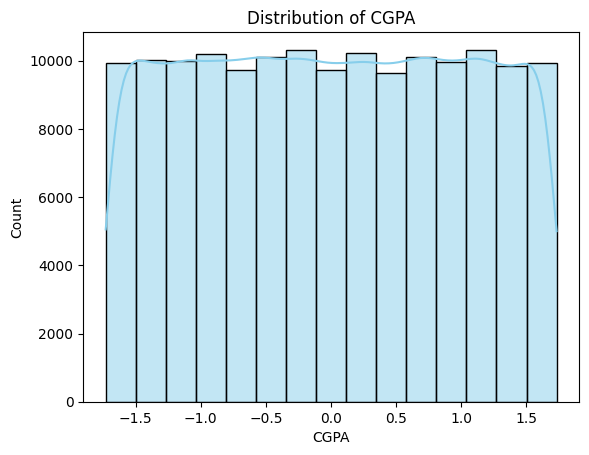

Skewness: 0.0013310445209663972
Kurtosis: -1.199447112698483


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Distribution plot
sns.histplot(df['cgpa'], kde=True, bins=15, color='skyblue')
plt.title("Distribution of CGPA")
plt.xlabel("CGPA")
plt.ylabel("Count")
plt.show()

# Skewness and kurtosis
print("Skewness:", skew(df['cgpa']))
print("Kurtosis:", kurtosis(df['cgpa']))

2. Plot a boxplot of cgpa by stress_level. What insights can you derive about the
relationship between stress and academic performance?

C:\Users\saba\AppData\Local\Temp\ipykernel_5068\1319525099.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y='cgpa', data=df, palette='Set2')


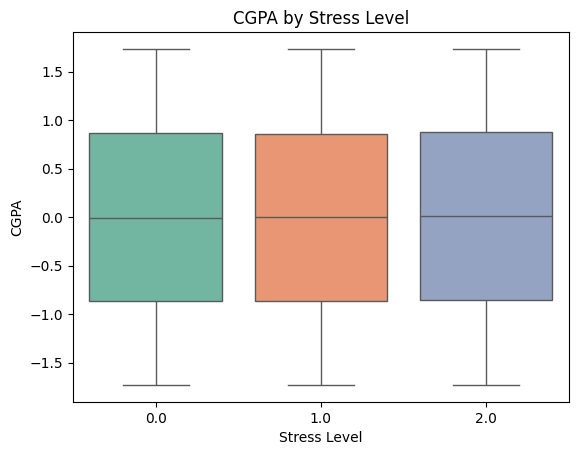

In [32]:
sns.boxplot(x='stress_level', y='cgpa', data=df, palette='Set2')
plt.title("CGPA by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("CGPA")
plt.show()

3. Create a bar plot showing average anxiety_score by gender. Which gender shows
higher anxiety, and does this align with common expectations?

C:\Users\saba\AppData\Local\Temp\ipykernel_5068\964849564.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender', y='anxiety_score', data=avg_anxiety, palette='pastel')


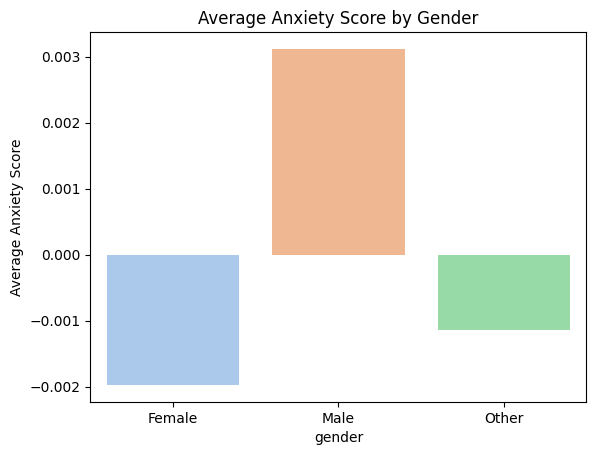

Gender with highest anxiety: Male


In [33]:
avg_anxiety = df.groupby('gender')['anxiety_score'].mean().reset_index()
sns.barplot(x='gender', y='anxiety_score', data=avg_anxiety, palette='pastel')
plt.title("Average Anxiety Score by Gender")
plt.ylabel("Average Anxiety Score")
plt.show()

# Gender with highest anxiety
highest_gender = avg_anxiety.loc[avg_anxiety['anxiety_score'].idxmax(), 'gender']
print("Gender with highest anxiety:", highest_gender)

4. Plot a scatter plot with daily_study_hours on x-axis and cgpa on y-axis, colored by
sleep_quality. What patterns emerge?

C:\Users\saba\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


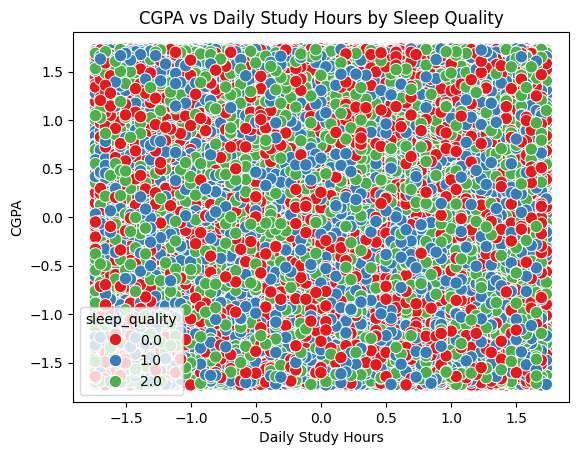

In [34]:
sns.scatterplot(x='daily_study_hours', y='cgpa', hue='sleep_quality', data=df, palette='Set1', s=80)
plt.title("CGPA vs Daily Study Hours by Sleep Quality")
plt.xlabel("Daily Study Hours")
plt.ylabel("CGPA")
plt.show()

5. Create a grouped bar chart showing the count of students in each burnout_level across
different course types. Which course has the highest burnout proportion?

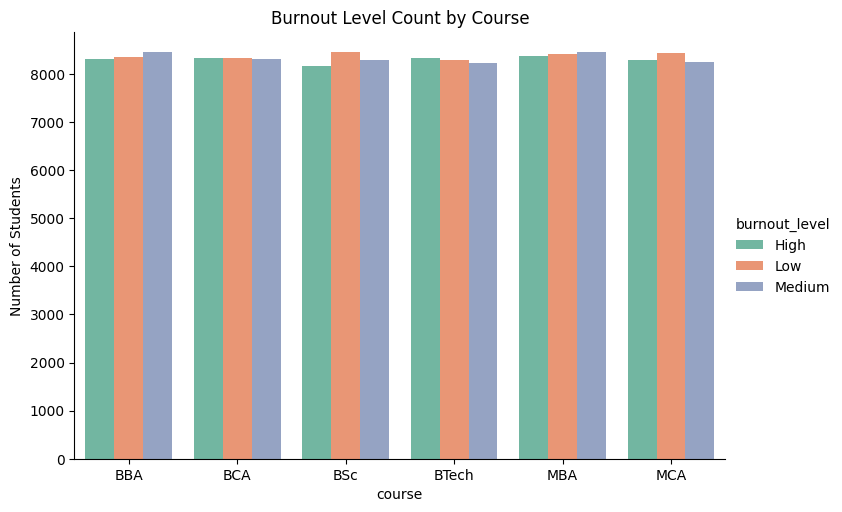

Course with highest proportion of high burnout: BTech


In [35]:
burnout_course = df.groupby(['course','burnout_level']).size().reset_index(name='count')
sns.catplot(x='course', y='count', hue='burnout_level', data=burnout_course,
            kind='bar', palette='Set2', height=5, aspect=1.5)
plt.title("Burnout Level Count by Course")
plt.ylabel("Number of Students")
plt.show()

# Course with highest burnout proportion
burnout_prop = df.groupby('course')['burnout_level'].value_counts(normalize=True).unstack()
highest_burnout_course = burnout_prop['High'].idxmax()
print("Course with highest proportion of high burnout:", highest_burnout_course)

6. Plot the distribution of screen_time_hours. Identify any extreme values and relate them
to depression_score.

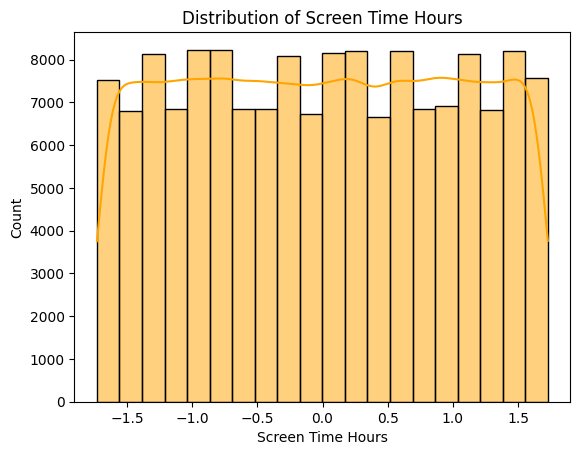

        screen_time_hours  depression_score
20               1.697794          0.175196
23               1.634880         -0.870460
35               1.603423          1.220852
102              1.729251          1.220852
109              1.697794         -0.870460
...                   ...               ...
149885           1.666337          0.523748
149916           1.666337         -0.870460
149924           1.634880          1.220852
149958           1.603423         -0.521908
149964           1.634880         -1.567564

[6171 rows x 2 columns]


In [36]:
sns.histplot(df['screen_time_hours'], kde=True, bins=20, color='orange')
plt.title("Distribution of Screen Time Hours")
plt.xlabel("Screen Time Hours")
plt.ylabel("Count")
plt.show()

# Extreme values
extreme_screen = df[df['screen_time_hours'] > df['screen_time_hours'].quantile(0.95)]
print(extreme_screen[['screen_time_hours','depression_score']])

7. Create a violin plot of cgpa by internet_quality. What does this suggest about internet
quality's impact on academics?

C:\Users\saba\AppData\Local\Temp\ipykernel_5068\4291320792.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='internet_quality', y='cgpa', data=df, palette='Set3')


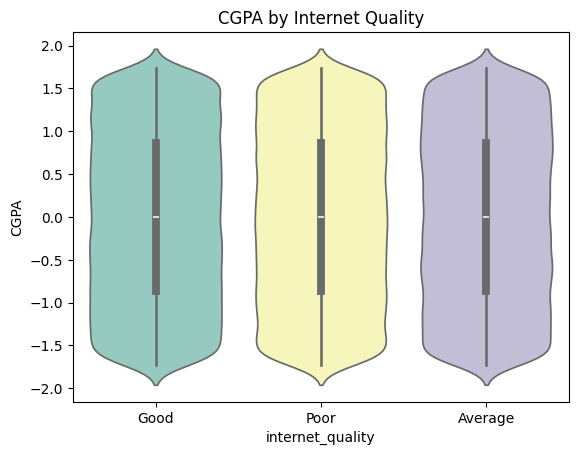

In [37]:
sns.violinplot(x='internet_quality', y='cgpa', data=df, palette='Set3')
plt.title("CGPA by Internet Quality")
plt.ylabel("CGPA")
plt.show()

8. Plot a heatmap of the correlation matrix for all numerical variables. Which features are
most correlated with cgpa? With anxiety_score?

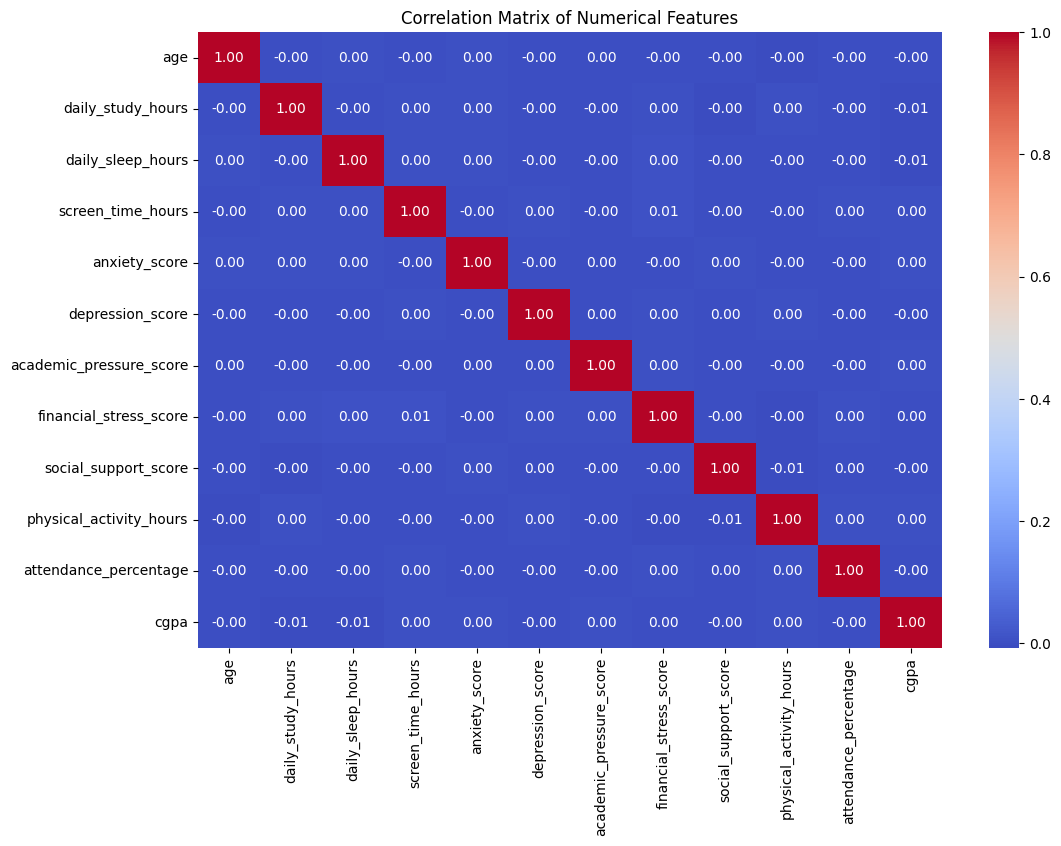

Top features correlated with CGPA:
 cgpa                       1.000000
screen_time_hours          0.002744
physical_activity_hours    0.002510
academic_pressure_score    0.001213
anxiety_score              0.001136
financial_stress_score     0.000553
social_support_score      -0.000425
depression_score          -0.002124
attendance_percentage     -0.002254
age                       -0.003290
daily_sleep_hours         -0.005004
daily_study_hours         -0.005450
Name: cgpa, dtype: float64
Top features correlated with Anxiety Score:
 anxiety_score              1.000000
daily_sleep_hours          0.003168
social_support_score       0.002810
daily_study_hours          0.002771
age                        0.001606
cgpa                       0.001136
academic_pressure_score    0.000503
attendance_percentage     -0.000118
screen_time_hours         -0.000441
financial_stress_score    -0.001421
physical_activity_hours   -0.001478
depression_score          -0.001782
Name: anxiety_score, dtype: 

In [38]:
numerical_cols = ['age','daily_study_hours','daily_sleep_hours','screen_time_hours',
                  'anxiety_score','depression_score','academic_pressure_score',
                  'financial_stress_score','social_support_score','physical_activity_hours',
                  'attendance_percentage','cgpa']

corr = df[numerical_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Features most correlated with cgpa and anxiety_score
print("Top features correlated with CGPA:\n", corr['cgpa'].sort_values(ascending=False))
print("Top features correlated with Anxiety Score:\n", corr['anxiety_score'].sort_values(ascending=False))

9. Create a pairplot for daily_study_hours, screen_time_hours, cgpa, and
anxiety_score. Which relationships appear non-linear?

In [ ]:
sns.pairplot(df, vars=['daily_study_hours','screen_time_hours','cgpa','anxiety_score'],
             hue='sleep_quality', palette='Set1', height=2.5)
plt.suptitle("Pairplot of Study Hours, Screen Time, CGPA, Anxiety", y=1.02)
plt.show()

10. Boxplot of academic_pressure_score by burnout_level. Is there a statistically
significant difference visible?

C:\Users\saba\AppData\Local\Temp\ipykernel_17648\3235694343.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_level', y='academic_pressure_score', data=df, palette='Set2')


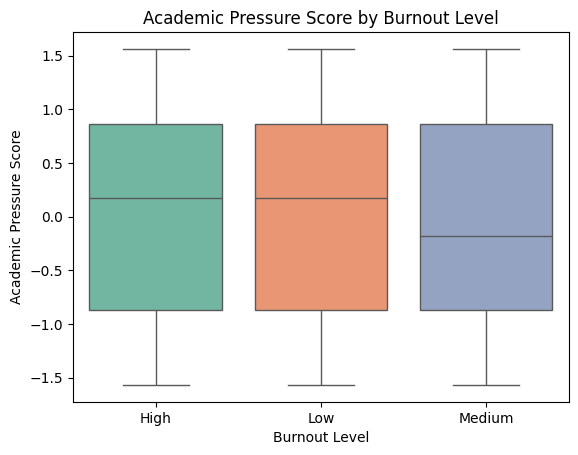

In [ ]:
sns.boxplot(x='burnout_level', y='academic_pressure_score', data=df, palette='Set2')
plt.title("Academic Pressure Score by Burnout Level")
plt.xlabel("Burnout Level")
plt.ylabel("Academic Pressure Score")
plt.show()

## Section 4: Model Building — Binary Classification

## Target Variable Creation

Create a binary target variable high_burnout where:
● 1 if burnout_level = "High"
● 0 if burnout_level = "Low" or "Medium"
Explain why you chose this binarization.


In [ ]:
# Create binary target
df['high_burnout'] = df['burnout_level'].apply(lambda x: 1 if x == 'High' else 0)

# Check distribution
print(df['high_burnout'].value_counts())

high_burnout
0    100234
1     49766
Name: count, dtype: int64


Explanation:

Binarization simplifies the problem to High vs Not High burnout.
Logistic Regression is for binary classification, so we convert multi-class (Low, Medium, High) into binary.

## Feature Selection

a. Which columns will you use as features (X) for prediction? Justify your selection.

age, daily_study_hours, daily_sleep_hours, screen_time_hours,
anxiety_score, depression_score, academic_pressure_score,
financial_stress_score, social_support_score, physical_activity_hours,
attendance_percentage, cgpa, gender, course, sleep_quality,
stress_level, internet_quality

Justification:

These features represent academic, psychological, and lifestyle factors that influence burnout.
They are independent variables that help predict high_burnout.
They do not directly contain the target information.

b. Which column is the target (y)?

In [ ]:
y = df['high_burnout']

c. Do you need to drop any columns to prevent data leakage? Identify them.

In [ ]:
# Drop columns that are outcomes or duplicates
drop_cols = ['burnout_level', 'student_id']  
X = X.drop(columns=[col for col in drop_cols if col in X])

Why:

burnout_level is the target in original form → including it would leak info.
student_id is unique → useless for prediction.

## Train-Test Split

a. Split the data into training and testing sets with 80–20 ratio and random_state = 42. Why is
random_state important?

In [ ]:
# Split numeric X_encoded
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
print("Training Accuracy:", train_acc)

Training Accuracy: 0.6687916666666667


Why random_state?

Ensures reproducible results. Every run will split the data the same way.

b. What is the purpose of splitting the dataset before training?

Purpose of splitting:

Train set → used to fit the model
Test set → used to evaluate model performance on unseen data, avoiding overfitting.

## Model Initialization & Training

a. Initialize a Logistic Regression model with max_iter = 1000. Why might you need to increase
max_iter?

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize model
model = LogisticRegression(max_iter=1000)  # increase max_iter to ensure convergence

b. Fit the model on the training data. What is the training accuracy score?

In [ ]:
# Fit on training data
model.fit(X_train, y_train)

# Training accuracy
train_acc = accuracy_score(y_train, model.predict(X_train))
print("Training Accuracy:", train_acc)

Training Accuracy: 0.6687916666666667


## Section 5: Model Evaluation

## Predictions & Metrics



a. Predict on the test set and calculate accuracy, precision, recall, and F1-score.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predict on test set
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))

Accuracy: 0.666
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


c:\Users\saba\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


b. Generate and interpret the confusion matrix.

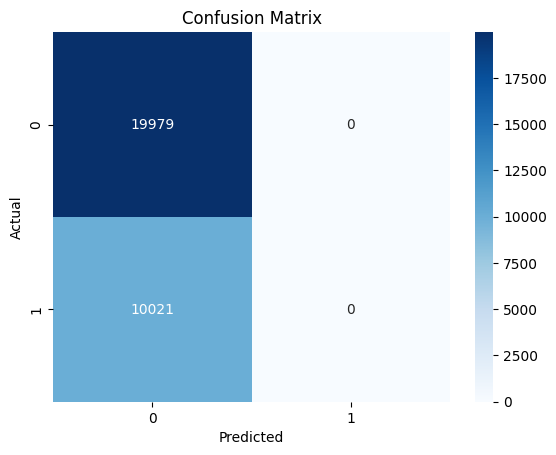

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## ROC-AUC Analysis

a. Plot the ROC curve and calculate the AUC score. What does this tell you about model
discriminative ability?

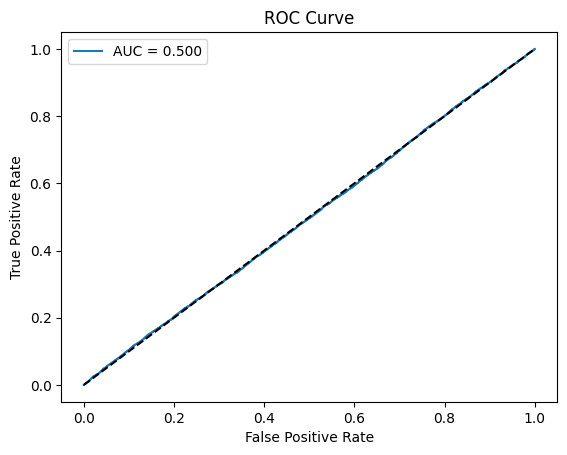

AUC Score: 0.5


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities for positive class
y_prob = model.predict_proba(X_test)[:,1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", round(auc_score,3))

b. If AUC is below 0.7, what might be the reasons?

If AUC is below 0.7, possible reasons are:

Weak relationship between features and target which means model cannot distinguish classes well
Class imbalance (model biased toward majority class)
Poor feature selection (important variables missing or irrelevant ones included)
Noisy data or outliers (reduces model performance)
Underfitting (model too simple to capture patterns)
This means the model has low discriminative ability (close to random)

## Classification Report Analysis

Provide and interpret the classification report. Which class (high_burnout = 0 or 1) is the model
better at predicting? Why might this be happening?


In [1]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

NameError: name 'y_test' is not defined

Interpretation:

support → number of samples in each class
precision → how many predicted positives were correct
recall → how many actual positives were correctly detected
F1-score → balance of precision and recall

## Section 6: Model Interpretation & Critical Thinking


a. Extract and interpret the coefficients of the logistic regression model. Which features have the
strongest positive and negative influence on predicting high burnout?


In [ ]:
coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coef)
print("Top Positive (increase burnout):")
print(coef.head(5))

print("\nTop Negative (decrease burnout):")
print(coef.tail(5))

NameError: name 'pd' is not defined

b. How would you explain the impact of academic_pressure_score on burnout odds to a
non-technical stakeholder?

If coefficient is positive → higher academic pressure increases chance of high burnout
If coefficient is negative → higher academic pressure decreases burnout

Simple explanation:
“Each increase in academic pressure makes students more likely to experience high burnout.”

## Class Imbalance Handling

a. Check the class distribution of high_burnout. Is there imbalance?

In [ ]:
print(df['high_burnout'].value_counts())
print(df['high_burnout'].value_counts(normalize=True))

NameError: name 'df' is not defined

Interpretation:
If one class (0 or 1) is much higher → imbalanced dataset
Example:
0 = 80%, 1 = 20% → imbalance exists
This can cause model to predict majority class better

## Preprocessing Impact Assessment


a. Train the model again without feature scaling. Compare coefficients and performance. Why
does scaling matter for logistic regression?

In [ ]:
# Train model WITHOUT scaling
model_ns = LogisticRegression(max_iter=1000)
model_ns.fit(X_train, y_train)

# Accuracy
from sklearn.metrics import accuracy_score
y_pred_ns = model_ns.predict(X_test)
print("Accuracy (No Scaling):", accuracy_score(y_test, y_pred_ns))

# Coefficients
coef_ns = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_ns.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coef_ns.head())

why: 
Features with large values dominate → biased coefficients
Slower convergence
Scaling ensures fair contribution of all features

b. Train the model without outlier treatment. How does performance change?

In [ ]:
# Train model on original (non-outlier-treated data)
model_no_out = LogisticRegression(max_iter=1000)
model_no_out.fit(X_train, y_train)

y_pred_no_out = model_no_out.predict(X_test)
print("Accuracy (No Outlier Treatment):", accuracy_score(y_test, y_pred_no_out))

Comment:

If accuracy drops → outliers were affecting model
If same → dataset already clean

## Model Improvement Strategies

a. If you wanted to improve model accuracy further, what additional steps could you take?
Propose at least 3 specific strategies with justification.


Improve accuracy (3 methods)
Feature Engineering
Create new features (e.g., study/sleep ratio)
Captures hidden relationships
Hyperparameter Tuning
Tune C in LogisticRegression
Controls regularization strength
Handle Class Imbalance
Use class_weight='balanced' or SMOTE
Improves prediction for minority class (high burnout)

b. Try L1 (Lasso) regularization and compare feature selection with your original model. Which
features become zero coefficients?

In [ ]:
# L1 regularization
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
model_l1.fit(X_train, y_train)

# Coefficients
coef_l1 = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_l1.coef_[0]
})

# Features with zero coefficients
zero_features = coef_l1[coef_l1['Coefficient'] == 0]
print("Zero Coefficient Features:\n", zero_features)

Interpretation:

L1 sets some coefficients to 0 → removes irrelevant features
Remaining features are most important for prediction